# ISL Default: Logistic Regression vs. LDA

Executed analysis of the **Default** dataset from *An Introduction to Statistical Learning*.

**Data provenance.** The uploaded workbook `Default.xlsx` contains the expected 10,000 observations and columns `default`, `student`, `balance`, and `income`, plus an index column. For reproducibility, this notebook uses an accompanying local `Default.csv` when present. The canonical dataset is distributed with the CRAN **ISLR** package; a commonly used machine-readable mirror is `https://vincentarelbundock.github.io/Rdatasets/csv/ISLR/Default.csv`.

The uploaded data—not synthetic data—were used for all results below.


In [1]:
import sys, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
import statsmodels, statsmodels.api as sm, sklearn
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import *
SEED=42; BOOT_SEED=20260920
print("Python",sys.version.split()[0])
print("numpy",np.__version__,"pandas",pd.__version__,"matplotlib",matplotlib.__version__)
print("statsmodels",statsmodels.__version__,"scikit-learn",sklearn.__version__)

Python 3.13.5
numpy 2.3.5 pandas 2.2.3 matplotlib 3.10.8
statsmodels 0.14.6 scikit-learn 1.8.0


## 1. Load and inspect data

In [2]:
from pathlib import Path
DATA=Path("Default.csv")
SOURCE="https://vincentarelbundock.github.io/Rdatasets/csv/ISLR/Default.csv"
if DATA.exists():
    raw=pd.read_csv(DATA)
else:
    raw=pd.read_csv(SOURCE); raw.to_csv(DATA,index=False)
df=raw.drop(columns=[c for c in raw.columns if str(c).lower() in {"unnamed: 0","rownames","row.names","x"}],errors="ignore")
assert len(df)==10000 and {"default","student","balance","income"}.issubset(df.columns)
print("Shape:",df.shape); print(df.head().to_string(index=False))
print("\nDtypes:\n",df.dtypes); print("\nMissing:\n",df.isna().sum())
print("\nDefault:\n",df.default.value_counts()); print("\nStudent:\n",df.student.value_counts())

Shape: (10000, 4)
default student     balance       income
     No      No  729.526495 44361.625074
     No     Yes  817.180407 12106.134700
     No      No 1073.549164 31767.138947
     No      No  529.250605 35704.493935
     No      No  785.655883 38463.495879

Dtypes:
 default     object
student     object
balance    float64
income     float64

Missing:
 default    0
student    0
balance    0
income     0

Default:
 default
No     9667
Yes     333
Name: count, dtype: int64

Student:
 student
No     7056
Yes    2944
Name: count, dtype: int64


## 2. One fair stratified split

`default=Yes` is encoded 1 and `student=Yes` is encoded 1. Both models use exactly `student`, `balance`, and `income`, and the identical stratified 70/30 split (`random_state=42`). Stratification preserves the rare default rate. No oversampling, class weighting, or test-set tuning is used. ROC AUC evaluates discrimination across thresholds; average precision complements it under strong class imbalance.


In [3]:
df["default_bin"]=df.default.map({"No":0,"Yes":1})
df["student_bin"]=df.student.map({"No":0,"Yes":1})
X=df[["student_bin","balance","income"]]; y=df.default_bin
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.30,random_state=42,stratify=y)
print(Xtr.shape,Xte.shape)
print("Test prevalence:",yte.mean())

(7000, 3) (3000, 3)
Test prevalence: 0.033333


## 3. Unpenalized logistic regression

In [4]:
Xtr_sm=sm.add_constant(Xtr.rename(columns={"student_bin":"student"}))
Xte_sm=sm.add_constant(Xte.rename(columns={"student_bin":"student"}))
fit=sm.Logit(ytr,Xtr_sm).fit(disp=False,maxiter=200)
print(fit.params)
ci=fit.conf_int()
print(pd.DataFrame({"OR":np.exp(fit.params),"low":np.exp(ci[0]),"high":np.exp(ci[1])}))
p_log=fit.predict(Xte_sm).to_numpy()
assert np.isfinite(p_log).all() and np.all((p_log>=0)&(p_log<=1))

const     -10.968932
student    -0.618734
balance     0.005841
income      0.000002
dtype: float64

         Odds ratio  OR 95% low  OR 95% high
const      0.000017    0.000005     0.000054
student    0.538626    0.312493     0.928397
balance    1.005859    1.005301     1.006416
income     1.000002    0.999983     1.000021


Conditional, associational interpretations (training-sample model-based intervals): `student=Yes` has an estimated odds ratio of **0.539** relative to non-students, holding balance and income fixed. A **$100** higher balance corresponds to an estimated odds multiplier of **1.793**; a **$1,000** higher income corresponds to **1.002**. These are associations, not causal effects.


## 4. Linear Discriminant Analysis

In [5]:
lda=LinearDiscriminantAnalysis().fit(Xtr,ytr)
pos=np.where(lda.classes_==1)[0][0]
p_lda=lda.predict_proba(Xte)[:,pos]
print("Priors:",dict(zip(lda.classes_,lda.priors_)))
print(pd.DataFrame(lda.means_,index=lda.classes_,columns=["student","balance","income"]))
assert np.isfinite(p_lda).all() and np.all((p_lda>=0)&(p_lda<=1))

Priors: {np.int64(0): np.float64(0.9667142857142857), np.int64(1): np.float64(0.03328571428571429)}
    student      balance        income
0  0.292153   806.215875  33530.996634
1  0.399142  1744.364290  31626.773248


LDA assumes class-conditional multivariate Gaussian predictors with a shared covariance matrix. The binary `student` predictor does not literally satisfy a continuous Gaussian assumption, although LDA can still be fitted and evaluated.

## 5. Held-out predictive performance

In [6]:
def metrics_row(prob):
    pred=(prob>=.5).astype(int); tn,fp,fn,tp=confusion_matrix(yte,pred,labels=[0,1]).ravel()
    return [roc_auc_score(yte,prob),average_precision_score(yte,prob),accuracy_score(yte,pred),
            precision_score(yte,pred,zero_division=0),recall_score(yte,pred),
            tn/(tn+fp),f1_score(yte,pred)]
M=pd.DataFrame([metrics_row(p_log),metrics_row(p_lda)],index=["Logistic","LDA"],
 columns=["ROC AUC","Average precision","Accuracy","Precision","Sensitivity","Specificity","F1"])
print(M)
print("Always-No accuracy:",(yte==0).mean())

                      ROC AUC  Average precision  Accuracy  Precision  Recall / sensitivity  Specificity        F1
Logistic regression  0.951069           0.503380  0.971667   0.647059                  0.33     0.993793  0.437086
LDA                  0.950845           0.503022  0.971333   0.694444                  0.25     0.996207  0.367647
Always-No accuracy: 0.9666666666666667


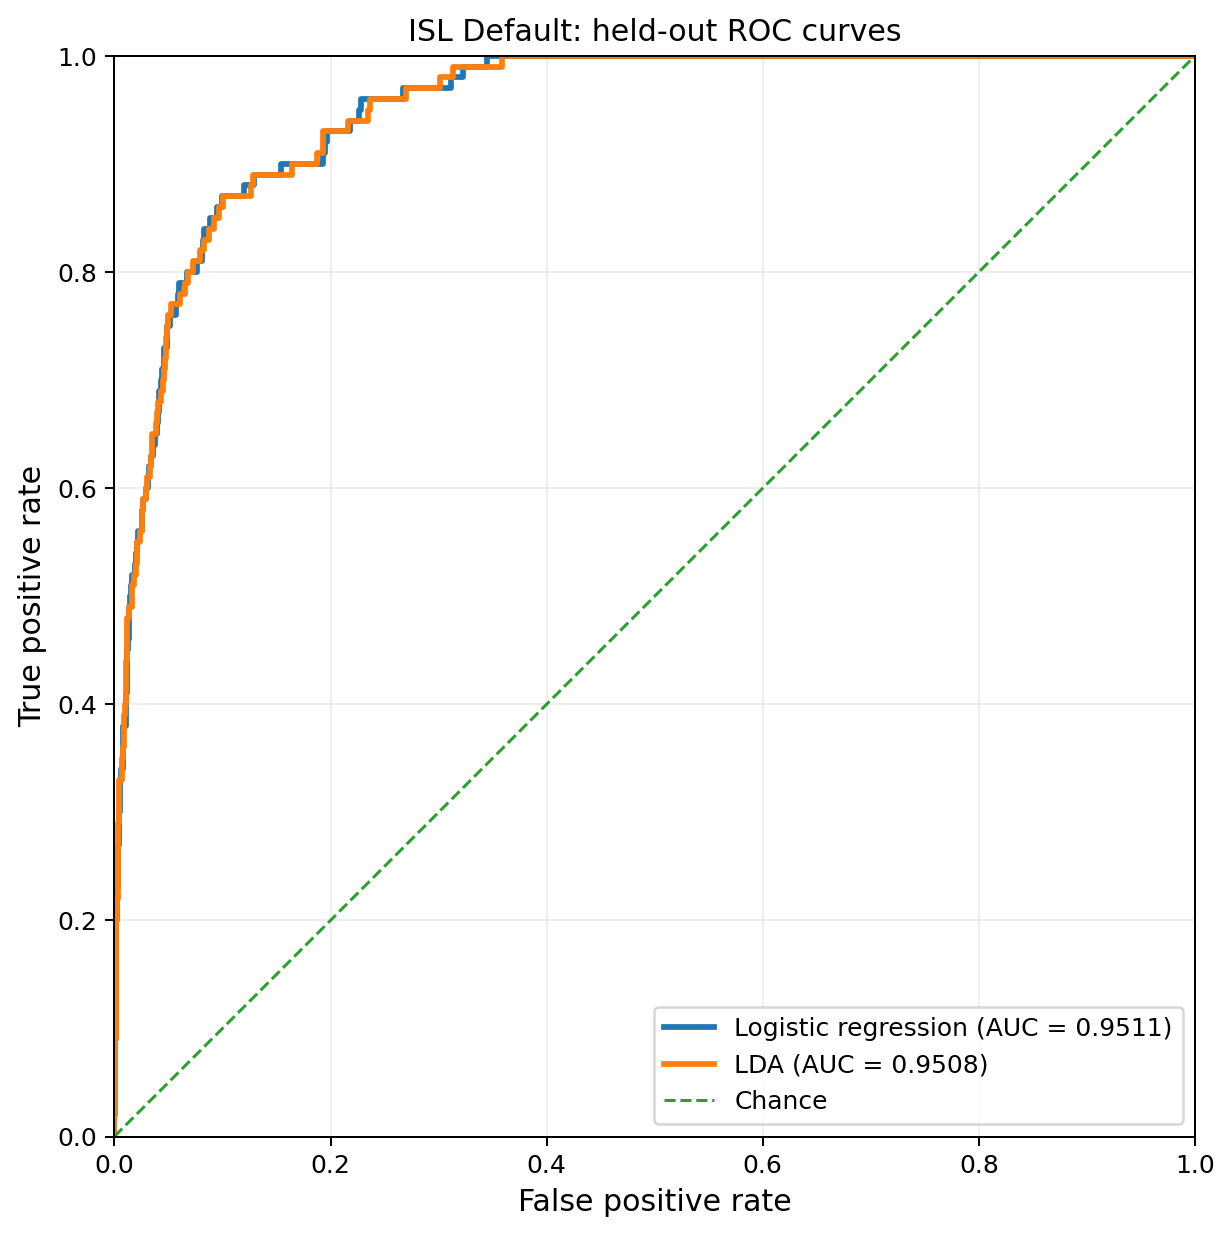

In [7]:
f1,t1,_=roc_curve(yte,p_log); f2,t2,_=roc_curve(yte,p_lda)
fig,ax=plt.subplots(figsize=(7,7))
ax.plot(f1,t1,lw=2.3,label=f"Logistic regression (AUC={roc_auc_score(yte,p_log):.4f})")
ax.plot(f2,t2,lw=2.3,label=f"LDA (AUC={roc_auc_score(yte,p_lda):.4f})")
ax.plot([0,1],[0,1],"--",label="Chance")
ax.set(xlabel="False positive rate",ylabel="True positive rate",xlim=(0,1),ylim=(0,1))
ax.set_aspect("equal"); ax.grid(alpha=.2); ax.legend(loc="lower right"); plt.show()

In [8]:
for name,p in [("Logistic",p_log),("LDA",p_lda)]:
    print(name); print(confusion_matrix(yte,(p>=.5).astype(int),labels=[0,1]))

Logistic
[[2882   18]
 [  67   33]]
LDA
[[2889   11]
 [  75   25]]


At threshold 0.5, sensitivity is modest because default is rare. ROC AUC assesses ranking across thresholds; average precision is a useful complementary measure. No threshold was selected using the test set.

### 2,000 paired stratified bootstrap resamples

In [9]:
rng=np.random.default_rng(20260920); ya=yte.to_numpy()
i0=np.flatnonzero(ya==0); i1=np.flatnonzero(ya==1)
bl=np.empty(2000); bd=np.empty(2000)
for b in range(2000):
    ix=np.r_[rng.choice(i0,len(i0),replace=True),rng.choice(i1,len(i1),replace=True)]
    rng.shuffle(ix)
    bl[b]=roc_auc_score(ya[ix],p_log[ix]); bd[b]=roc_auc_score(ya[ix],p_lda[ix])
d=bl-bd
for name,a,est in [("Logistic",bl,roc_auc_score(yte,p_log)),("LDA",bd,roc_auc_score(yte,p_lda)),
                   ("Difference",d,roc_auc_score(yte,p_log)-roc_auc_score(yte,p_lda))]:
    print(name,est,np.percentile(a,[2.5,97.5]))

Logistic 0.951069 [0.93401    0.96532526]
LDA 0.950845 [0.93384767 0.96497767]
Difference 0.000224 [-0.0005      0.00093112]


## Conclusion

On this one held-out split, logistic regression has ROC AUC **0.9511** and LDA **0.9508**, an estimated difference (logistic − LDA) of **0.0002**. The paired stratified-bootstrap 95% interval for that difference is **[-0.0005, 0.0009]**. The curves are extremely close, so the data do not support treating the tiny observed AUC difference as a convincing practical advantage.

These bootstrap intervals condition on the fitted models and capture test-sample uncertainty only; they do **not** include training-sample variability. A single train/test split is also intrinsically limited.


## 7. Full-data fits and training ROC comparison

For a descriptive in-sample comparison, both models are now refitted using **all 10,000 observations**, with the same three predictors: `student`, `balance`, and `income`. Their ROC curves are then computed on those same observations.

These are **training ROC curves**, so they should not replace the held-out results above as estimates of out-of-sample performance. They are included to show how the two fitted scoring rules rank the complete dataset.


In [10]:
# Refit both models on all 10,000 observations
X_all = df[["student_bin", "balance", "income"]].copy()
y_all = df["default_bin"].astype(int)

# Unpenalized logistic regression with intercept
X_all_sm = sm.add_constant(
    X_all.rename(columns={"student_bin": "student"}), has_constant="add"
)
logit_all = sm.Logit(y_all, X_all_sm).fit(disp=False, maxiter=200)
p_log_all = np.asarray(logit_all.predict(X_all_sm))

# LDA, with priors estimated from the full data
lda_all = LinearDiscriminantAnalysis()
lda_all.fit(X_all, y_all)
positive_col = np.where(lda_all.classes_ == 1)[0][0]
p_lda_all = lda_all.predict_proba(X_all)[:, positive_col]

assert np.isfinite(p_log_all).all() and np.all((p_log_all >= 0) & (p_log_all <= 1))
assert np.isfinite(p_lda_all).all() and np.all((p_lda_all >= 0) & (p_lda_all <= 1))

auc_log_all = roc_auc_score(y_all, p_log_all)
auc_lda_all = roc_auc_score(y_all, p_lda_all)
ap_log_all = average_precision_score(y_all, p_log_all)
ap_lda_all = average_precision_score(y_all, p_lda_all)

full_metrics = pd.DataFrame({
    "Training ROC AUC": [auc_log_all, auc_lda_all],
    "Training average precision": [ap_log_all, ap_lda_all],
}, index=["Logistic regression", "LDA"])
display(full_metrics.style.format("{:.6f}"))

print("AUC difference (Logistic - LDA):", f"{auc_log_all - auc_lda_all:.6f}")
print("\nFull-data logistic coefficients:")
display(logit_all.params.to_frame("coefficient"))
print("Full-data LDA priors:", dict(zip(lda_all.classes_, lda_all.priors_)))


,Training ROC AUC,Training average precision
Logistic regression,0.949558,0.531049
LDA,0.949520,0.530074


AUC difference (Logistic - LDA): 0.000038

Full-data logistic coefficients:
const     -10.869045
student    -0.646776
balance     0.005737
income      0.000003

Full-data LDA priors: {0: 0.9667, 1: 0.0333}


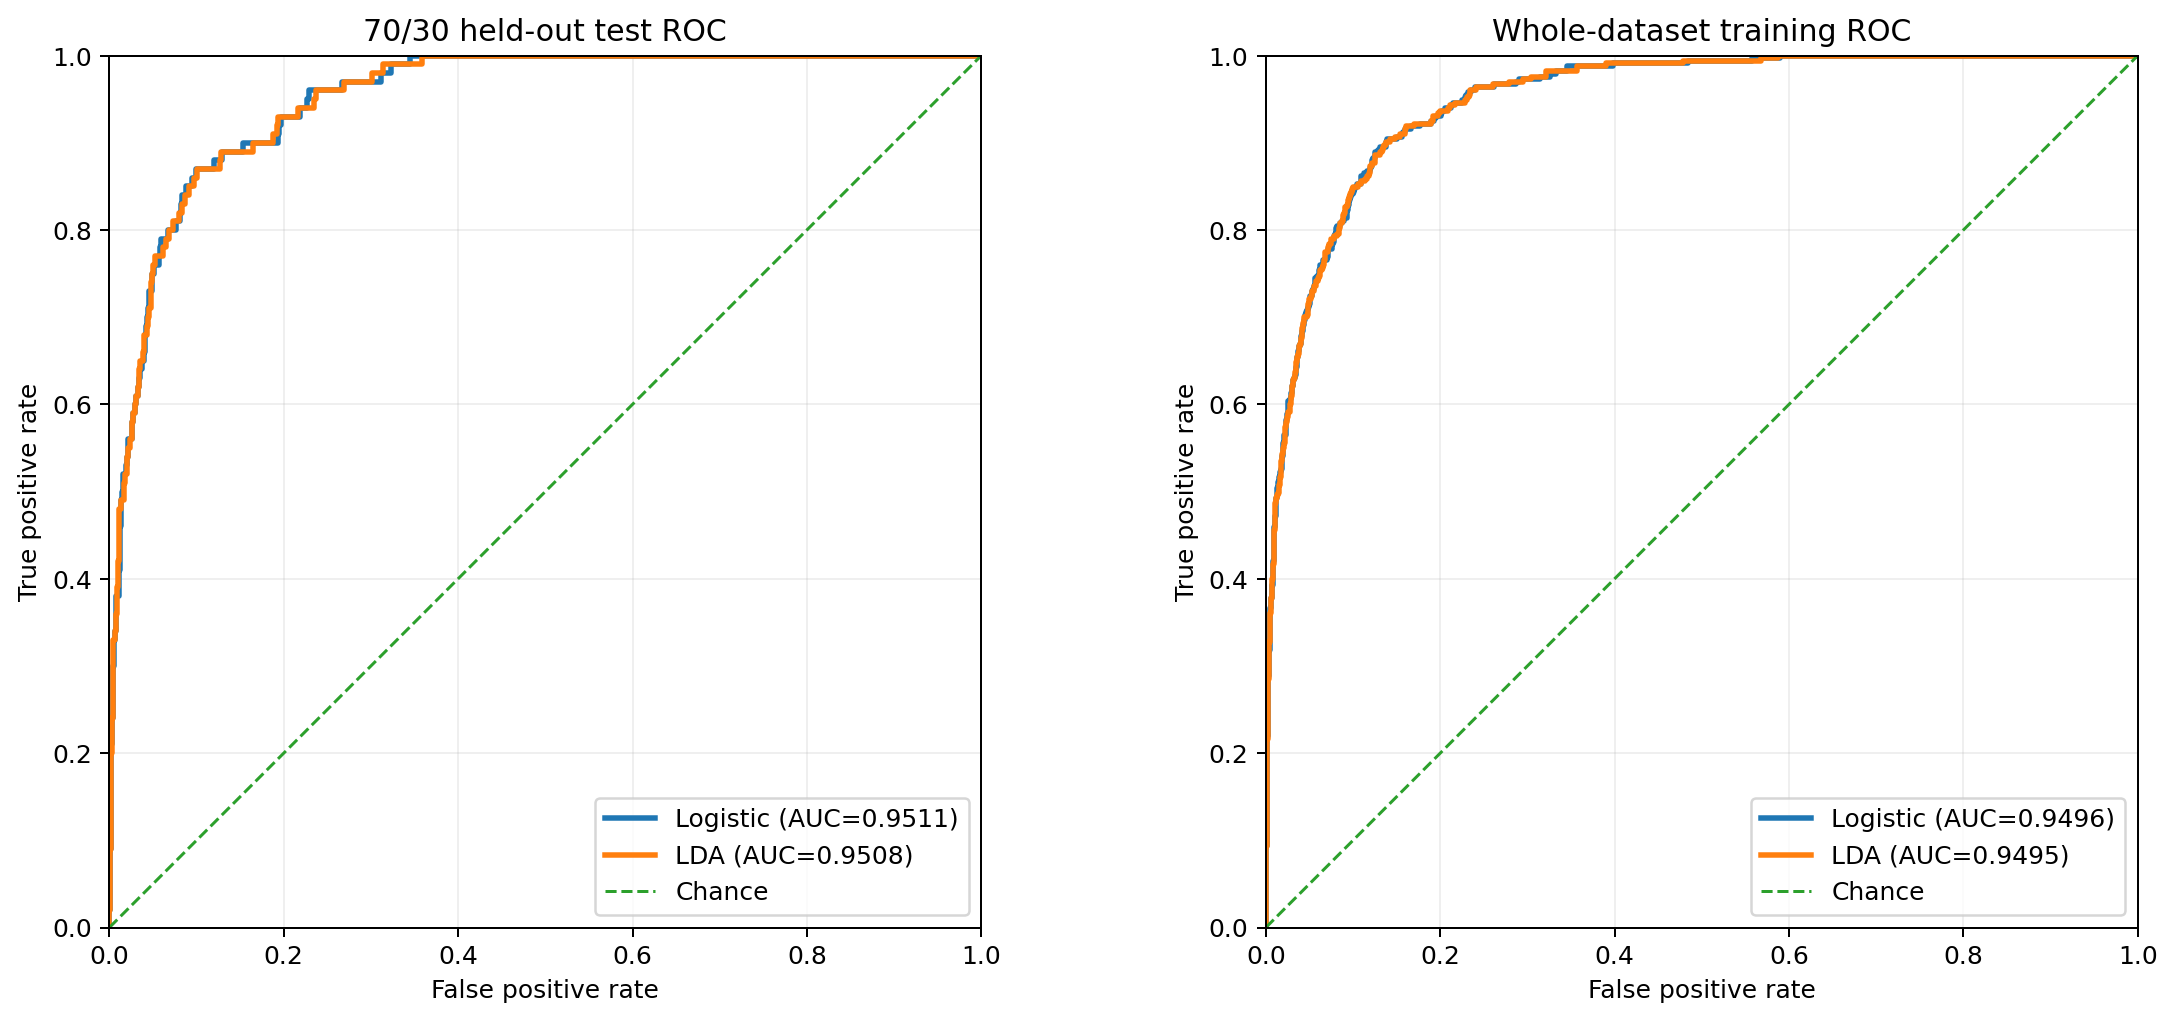

In [11]:
# Held-out and training ROC curves side by side
fpr_test_log, tpr_test_log, _ = roc_curve(yte, p_log)
fpr_test_lda, tpr_test_lda, _ = roc_curve(yte, p_lda)
fpr_all_log, tpr_all_log, _ = roc_curve(y_all, p_log_all)
fpr_all_lda, tpr_all_lda, _ = roc_curve(y_all, p_lda_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

# Held-out panel
axes[0].plot(fpr_test_log, tpr_test_log, lw=2.2,
             label=f"Logistic (AUC={roc_auc_score(yte,p_log):.4f})")
axes[0].plot(fpr_test_lda, tpr_test_lda, lw=2.2,
             label=f"LDA (AUC={roc_auc_score(yte,p_lda):.4f})")
axes[0].plot([0,1], [0,1], "--", lw=1.2, label="Chance")
axes[0].set_title("70/30 held-out test ROC")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=.2); axes[0].legend(loc="lower right")

# Full-data training panel
axes[1].plot(fpr_all_log, tpr_all_log, lw=2.2,
             label=f"Logistic (AUC={auc_log_all:.4f})")
axes[1].plot(fpr_all_lda, tpr_all_lda, lw=2.2,
             label=f"LDA (AUC={auc_lda_all:.4f})")
axes[1].plot([0,1], [0,1], "--", lw=1.2, label="Chance")
axes[1].set_title("Whole-dataset training ROC")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=.2); axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


### Comparison

The held-out AUCs were **0.9511** (logistic) and **0.9508** (LDA). After refitting on all 10,000 observations, the in-sample training AUCs are **0.9496** and **0.9495**, respectively.

In both evaluations the curves are nearly coincident. The full-data training AUC difference is only **0.000038**. The training ROC is descriptive and optimistic in principle because the same observations are used for fitting and evaluation; the held-out comparison remains the more appropriate assessment of predictive generalization.


## 8. Revisiting the original MAFS6010 notebook

The original `MAFS6010_Classification.ipynb` used scikit-learn's then-default `LogisticRegression()`, whose stored representation shows `penalty='l2'`, `solver='liblinear'`, and `C=1.0`. It fitted the raw predictors `balance`, `income`, and `student` without standardization.

That is not the same estimator as the unpenalized maximum-likelihood logistic regression used above. More importantly, the three raw predictors have very different numerical scales: `student` is binary, `balance` is typically on the order of thousands, and `income` on the order of tens of thousands. L2 regularization acts on coefficient magnitudes, so applying it to unscaled predictors can strongly distort the fitted scoring rule.

To diagnose the discrepancy directly, the following cell fits four models to **the identical 10,000 observations and identical three predictors**:

1. old-style, unscaled L2 `liblinear`;
2. the same `liblinear` model after standardizing the predictors;
3. unpenalized maximum-likelihood `statsmodels.Logit`;
4. LDA.

All ROC curves below are in-sample training curves, so the purpose is diagnostic rather than an estimate of future predictive performance.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_revisit = df[["student_bin", "balance", "income"]].copy()
y_revisit = df["default_bin"].astype(int)

# 1) Approximate the old sklearn notebook configuration:
old_liblinear = LogisticRegression(
    solver="liblinear", penalty="l2", C=1.0, max_iter=1000
)
old_liblinear.fit(X_revisit, y_revisit)
p_old = old_liblinear.predict_proba(X_revisit)[:, np.where(old_liblinear.classes_ == 1)[0][0]]

# 2) Same penalized liblinear estimator, but standardize predictors first.
scaled_liblinear = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear", penalty="l2", C=1.0, max_iter=1000)
)
scaled_liblinear.fit(X_revisit, y_revisit)
lr_scaled = scaled_liblinear.named_steps["logisticregression"]
p_scaled = scaled_liblinear.predict_proba(X_revisit)[:, np.where(lr_scaled.classes_ == 1)[0][0]]

# 3) Unpenalized maximum-likelihood logistic regression.
X_revisit_sm = sm.add_constant(
    X_revisit.rename(columns={"student_bin": "student"}), has_constant="add"
)
unpenalized = sm.Logit(y_revisit, X_revisit_sm).fit(disp=False, maxiter=200)
p_unpen = np.asarray(unpenalized.predict(X_revisit_sm))

# 4) LDA.
lda_revisit = LinearDiscriminantAnalysis().fit(X_revisit, y_revisit)
p_lda_revisit = lda_revisit.predict_proba(X_revisit)[:, np.where(lda_revisit.classes_ == 1)[0][0]]

revisit_probs = {
    "Old-style unscaled liblinear": p_old,
    "Scaled liblinear": p_scaled,
    "Unpenalized Logit": p_unpen,
    "LDA": p_lda_revisit,
}

revisit_auc = pd.Series(
    {name: roc_auc_score(y_revisit, p) for name, p in revisit_probs.items()},
    name="Training ROC AUC"
)
display(revisit_auc.to_frame().style.format("{:.6f}"))

print("Old-style unscaled liblinear intercept:", old_liblinear.intercept_[0])
print("Old-style unscaled liblinear coefficients:")
display(pd.Series(old_liblinear.coef_[0], index=["student","balance","income"], name="coefficient").to_frame())
print("\nUnpenalized Logit coefficients:")
display(unpenalized.params.to_frame("coefficient"))


,Training ROC AUC
Old-style unscaled liblinear,0.595079
Scaled liblinear,0.949564
Unpenalized Logit,0.949558
LDA,0.949520


Old-style unscaled liblinear    0.595079
Scaled liblinear                0.949564
Unpenalized Logit               0.949558
LDA                             0.949520

Old-style unscaled liblinear intercept: -1.9417968062472894e-06
Old-style coefficients:
student   -0.000003
balance    0.000408
income    -0.000126

Unpenalized Logit coefficients:
const     -10.869045
student    -0.646776
balance     0.005737
income      0.000003


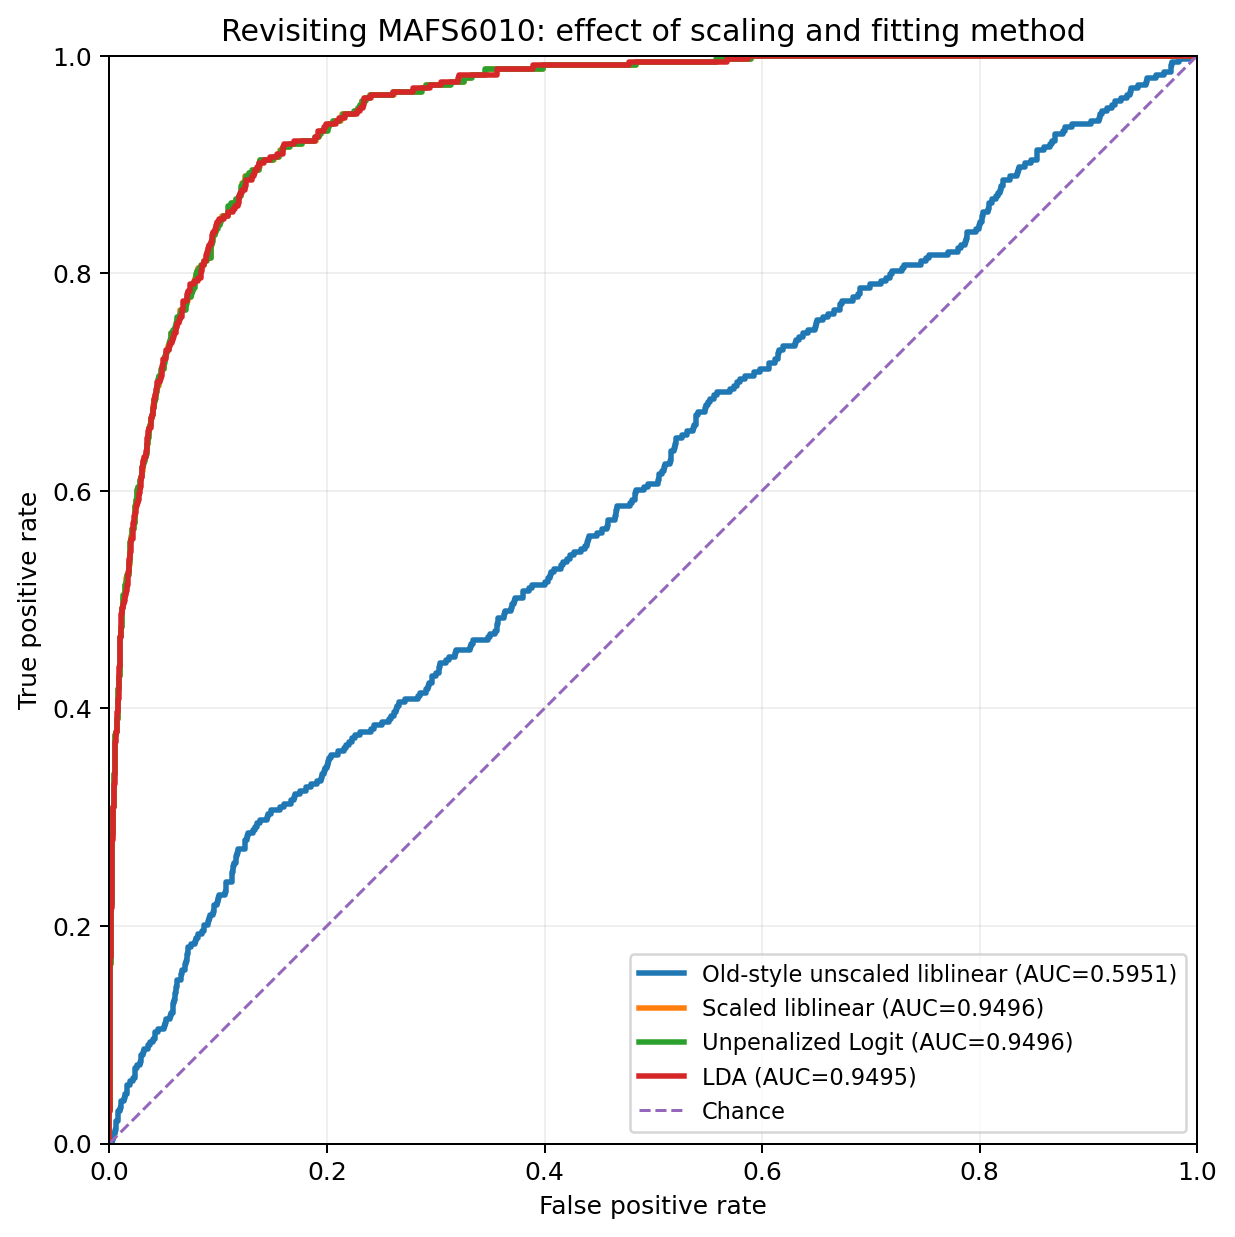

In [13]:
fig, ax = plt.subplots(figsize=(8,7))
for name, p in revisit_probs.items():
    fpr, tpr, _ = roc_curve(y_revisit, p)
    auc = roc_auc_score(y_revisit, p)
    ax.plot(fpr, tpr, lw=2.2, label=f"{name} (AUC={auc:.4f})")
ax.plot([0,1], [0,1], "--", lw=1.2, label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Revisiting MAFS6010: effect of scaling and fitting method")
ax.grid(alpha=.2)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


### What this diagnostic shows

The old-style unscaled `liblinear` fit has training ROC AUC **0.5951**, far below the other three fits. Once the same penalized `liblinear` estimator is preceded by standardization, its AUC becomes **0.9496**, essentially identical to the unpenalized Logit (**0.9496**) and LDA (**0.9495**).

This supports the interpretation that the low logistic ROC in the original teaching notebook is primarily a **scaling + regularization/solver artifact**, rather than evidence that `income` intrinsically harms logistic-regression discrimination. The original notebook and this reproduction may use different scikit-learn versions, so the old-style current-version `liblinear` result should be read as a reproduction of the mechanism, not necessarily a bit-for-bit reproduction of historical solver behavior.

The statistical lesson is important: when penalized logistic regression is used, predictor scaling matters because the penalty is applied to coefficient magnitudes. By contrast, the unpenalized maximum-likelihood Logit fit above estimates the intended textbook logistic model directly.
